Makemore Part 2

In [75]:
words =open("/home/bukunmi/ml-journey/datasets/names.txt", "r").read().splitlines()

In [76]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt # for making figures
%matplotlib inline

In [77]:
len(words)

32033

In [78]:
# build the vocabulary of characters and mappings to/from integers
chars = sorted(list(set(''.join(words))))
stoi = {s:i+1 for i,s in enumerate(chars)}
stoi['.'] = 0
itos = {i:s for s,i in stoi.items()}
print(itos)

{1: 'a', 2: 'b', 3: 'c', 4: 'd', 5: 'e', 6: 'f', 7: 'g', 8: 'h', 9: 'i', 10: 'j', 11: 'k', 12: 'l', 13: 'm', 14: 'n', 15: 'o', 16: 'p', 17: 'q', 18: 'r', 19: 's', 20: 't', 21: 'u', 22: 'v', 23: 'w', 24: 'x', 25: 'y', 26: 'z', 0: '.'}


In [79]:
# build the dataset

block_size = 3 # context length: how many characters do we take to predict the next one?
X, Y = [], []
for w in words:
  
  #print(w)
  context = [0] * block_size
  for ch in w + '.':
    ix = stoi[ch]
    X.append(context)
    Y.append(ix)
    #print(''.join(itos[i] for i in context), '--->', itos[ix])
    context = context[1:] + [ix] # crop and append
  
X = torch.tensor(X)
Y = torch.tensor(Y)

In [80]:
X.shape, X.dtype, Y.shape, Y.dtype

(torch.Size([228146, 3]), torch.int64, torch.Size([228146]), torch.int64)

In [81]:
X.shape, X.dtype, Y.shape, Y.dtype
# build the dataset
block_size = 3 # context length: how many characters do we take to predict the next one?

def build_dataset(words):  
  X, Y = [], []
  for w in words:

    #print(w)
    context = [0] * block_size
    for ch in w + '.':
      ix = stoi[ch]
      X.append(context)
      Y.append(ix)
      #print(''.join(itos[i] for i in context), '--->', itos[ix])
      context = context[1:] + [ix] # crop and append

  X = torch.tensor(X)
  Y = torch.tensor(Y)
  print(X.shape, Y.shape)
  return X, Y

import random
random.seed(42)
random.shuffle(words)
n1 = int(0.8*len(words))
n2 = int(0.9*len(words))

Xtr, Ytr = build_dataset(words[:n1])
Xdev, Ydev = build_dataset(words[n1:n2])
Xte, Yte = build_dataset(words[n2:])

torch.Size([182625, 3]) torch.Size([182625])
torch.Size([22655, 3]) torch.Size([22655])
torch.Size([22866, 3]) torch.Size([22866])


In [82]:
C = torch.randn((27, 2))

In [83]:
emb = C[Xtr]
emb.shape

torch.Size([182625, 3, 2])

In [84]:
W1 = torch.randn((6, 100))
b1 = torch.randn(100)

In [85]:
h = torch.tanh(emb.view(-1, 6) @ W1 + b1)

In [86]:
h

tensor([[ 0.5749, -0.2082, -0.9335,  ..., -0.0723,  0.1367,  0.8881],
        [ 0.5605, -0.2888, -0.9853,  ...,  0.9942, -0.7745,  0.8649],
        [ 0.3844,  0.3777, -0.5042,  ..., -0.8545,  0.8565,  0.8401],
        ...,
        [ 0.9925, -0.0645, -0.6561,  ..., -0.9861,  0.8620,  0.1308],
        [ 0.9445, -0.9987, -0.4414,  ...,  0.2691, -0.6060, -0.5917],
        [ 0.9878, -0.8795, -0.4941,  ...,  0.9980, -0.8926, -0.4299]])

In [87]:
h.shape

torch.Size([182625, 100])

In [88]:
W2 = torch.randn((100, 27))
b2 = torch.randn(27)

In [89]:
logits = h @ W2 + b2

In [90]:
logits.shape

torch.Size([182625, 27])

In [91]:
counts = logits.exp()

In [92]:
prob = counts / counts.sum(1, keepdims=True)

In [93]:
prob.shape

torch.Size([182625, 27])

In [94]:
Y

tensor([ 5, 13, 13,  ..., 26, 24,  0])

In [95]:
loss = F.cross_entropy(logits, Ytr)
loss

tensor(17.1596)

Run Again

In [96]:
g = torch.Generator().manual_seed(2147483647) # for reproducibility
C = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]

In [97]:
sum(p.nelement() for p in parameters) # number of parameters in total

11897

In [98]:
for p in parameters:
  p.requires_grad = True

In [99]:
lre = torch.linspace(-3, 0, 1000)
lrs = 10**lre

In [100]:
lri = []
lossi = []
stepi = []

In [101]:
# LR finder: sweep lr from 1e-3 to 1.0 across 1000 steps and record the loss
lri = []
lossi = []

for i in range(1000):

  # minibatch construct
  ix = torch.randint(0, Xtr.shape[0], (32,))

  # forward pass
  emb = C[Xtr[ix]] # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1) # (32, 200)
  logits = h @ W2 + b2 # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])

  # backward pass
  for p in parameters:
    p.grad = None
  loss.backward()

  # update — use the swept LR
  lr = lrs[i]
  for p in parameters:
    p.data += -lr * p.grad

  # track stats
  lri.append(lre[i].item())
  lossi.append(loss.item())

Text(0, 0.5, 'loss')

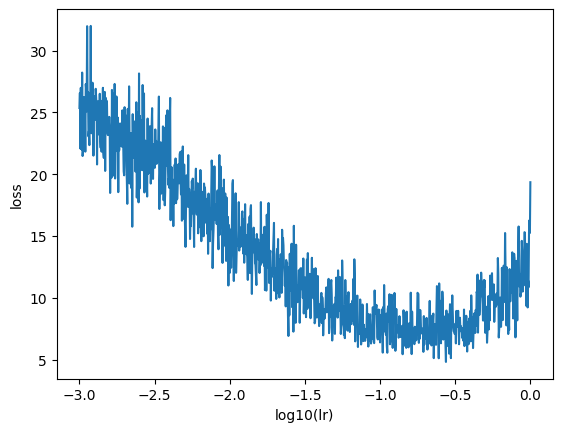

In [102]:
# LR-finder plot: x is log10(lr), y is loss. Pick the lr just before the loss elbows up.
plt.plot(lri, lossi)
plt.xlabel('log10(lr)')
plt.ylabel('loss')

### Real training run

LR finder above should show the loss elbowing around `log10(lr) ≈ -1` (i.e. `lr ≈ 0.1`). Re-initialize parameters cleanly (the LR sweep ended with huge LRs that mangled them) and train for real.

In [103]:
# Re-init parameters cleanly after the LR sweep
g = torch.Generator().manual_seed(2147483647)
C  = torch.randn((27, 10), generator=g)
W1 = torch.randn((30, 200), generator=g)
b1 = torch.randn(200, generator=g)
W2 = torch.randn((200, 27), generator=g)
b2 = torch.randn(27, generator=g)
parameters = [C, W1, b1, W2, b2]
for p in parameters:
  p.requires_grad = True

stepi = []
lossi = []

In [104]:
# Main training: 30k steps at lr=0.1
for i in range(30000):

  ix = torch.randint(0, Xtr.shape[0], (32,))

  emb = C[Xtr[ix]]                              # (32, 3, 10)
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1)    # (32, 200)
  logits = h @ W2 + b2                          # (32, 27)
  loss = F.cross_entropy(logits, Ytr[ix])

  for p in parameters:
    p.grad = None
  loss.backward()

  lr = 0.1
  for p in parameters:
    p.data += -lr * p.grad

  stepi.append(i)
  lossi.append(loss.log10().item())

print(f'final minibatch loss: {loss.item():.4f}')

final minibatch loss: 2.7832


In [105]:
# Decay phase: 10k more steps at lr=0.01
for i in range(10000):

  ix = torch.randint(0, Xtr.shape[0], (32,))

  emb = C[Xtr[ix]]
  h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
  logits = h @ W2 + b2
  loss = F.cross_entropy(logits, Ytr[ix])

  for p in parameters:
    p.grad = None
  loss.backward()

  lr = 0.01
  for p in parameters:
    p.data += -lr * p.grad

  stepi.append(30000 + i)
  lossi.append(loss.log10().item())

print(f'final minibatch loss: {loss.item():.4f}')

final minibatch loss: 1.9215


Text(0, 0.5, 'log10(loss)')

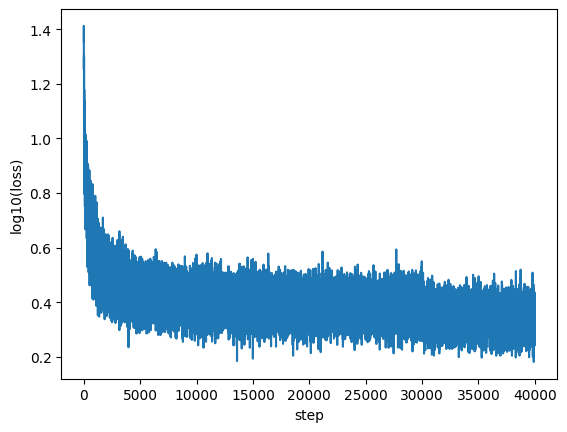

In [106]:
# Training loss curve (log10). Expect steep early drop, then a long noisy tail that levels lower after the decay.
plt.plot(stepi, lossi)
plt.xlabel('step')
plt.ylabel('log10(loss)')

In [107]:
# Evaluate on train and dev (full passes, no minibatch)
emb = C[Xtr]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
print(f'train loss: {F.cross_entropy(logits, Ytr).item():.4f}')

emb = C[Xdev]
h = torch.tanh(emb.view(-1, 30) @ W1 + b1)
logits = h @ W2 + b2
print(f'dev   loss: {F.cross_entropy(logits, Ydev).item():.4f}')

train loss: 2.2255
dev   loss: 2.2536


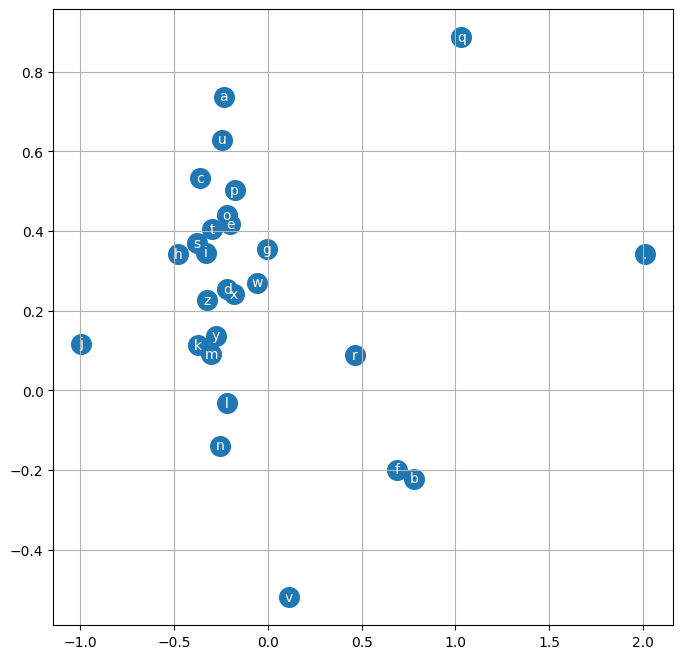

In [108]:
# visualize dimensions 0 and 1 of the embedding matrix C for all characters
plt.figure(figsize=(8,8))
plt.scatter(C[:,0].data, C[:,1].data, s=200)
for i in range(C.shape[0]):
    plt.text(C[i,0].item(), C[i,1].item(), itos[i], ha="center", va="center", color='white')
plt.grid('minor')

In [109]:
context = [0] * block_size
C[torch.tensor([context])].shape

torch.Size([1, 3, 10])

In [110]:
# sample from the model
g = torch.Generator().manual_seed(2147483647 + 10)

for _ in range(20):
    
    out = []
    context = [0] * block_size # initialize with all ...
    while True:
      emb = C[torch.tensor([context])] # (1,block_size,d)
      h = torch.tanh(emb.view(1, -1) @ W1 + b1)
      logits = h @ W2 + b2
      probs = F.softmax(logits, dim=1)
      ix = torch.multinomial(probs, num_samples=1, generator=g).item()
      context = context[1:] + [ix]
      out.append(ix)
      if ix == 0:
        break
    
    print(''.join(itos[i] for i in out))

carmahzari.
hariffirrightity.
salaysaeja.
hutn.
amerric.
kaeli.
nellara.
chaiivon.
lege.
halma.
kindelinn.
sroelea.
jadii.
watthoniearisi.
frani.
durathe.
deco.
abetley.
ysri.
allag.
